# [실습] 타이타닉 생존자 예측하기

### 참고
- [코드] https://www.kaggle.com/competitions/titanic/code 
- [코드] https://dacon.io/competitions/open/235539/codeshare/5042?page=1&dtype=recent 
- [빈 템플릿] https://dacon.io/competitions/open/235539/codeshare/1215?page=1&dtype=recent

### 목표
- 타이타닉 데이터를 이용하여 데이터 **변수간의 상관관계**를 확인해 본다.
- 사이킷런 분류 모델을 이용하여 타이타닉 **생존자를 예측하는 모델**을 만들어 본다.
- **모델을 평가**해 본다.

### 머신러닝 모델(분류)
- **로지스틱 회귀** 
- **결정트리** 
- **서포트벡터머신** 

### 평가지표
- 정확도(accuracy_score)
- 오차행렬(confusion_matrix)
- 정밀도(precision_score)
- 재현율(recall_score)
- F1점수(fi_score)
- ROC정확도(roc_auc_score)

## 1. 데이터 준비하기

- 다운로드:  https://www.kaggle.com/competitions/titanic/data 
- train.csv : 모델 학습에 사용되는 데이터 파일
- test.csv : 예측에 사용되는 탑승객들의 데이터 파일
- gender_submission.csv : 캐글에 제출하여 평가를 받을 파일

In [454]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

DIR = 'data/titanic/'
train = pd.read_csv(DIR+'train.csv')
test = pd.read_csv(DIR+'test.csv')
submission = pd.read_csv(DIR+'gender_submission.csv')
train.head()
# test
# submission

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


----------------------

## 2. 데이터 전처리

### 2-1. 기본 정보 확인

#### 데이터의 개수 확인

In [455]:
print(train.shape)
print(test.shape)
print(submission.shape)

(891, 12)
(418, 11)
(418, 2)


#### 컬럼정보 

In [528]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup', 'Fare2'],
      dtype='object')

| 필드명 | 설명 | 값 종류 |
|------|------|------|
|PassengerId |승객번호  |	|
|Survived |생존여부  |0=No, 1=Yes|	
|Pclass |티켓 클래스 |1=1st, 2=2nd, 3=3rd|	
|Name |이름  |	|	
|Sex |성별  |male=남, female=여	|	
|Age |나이  |	|	
|SibSp |타이타닉 밖의 형제자매/부부의 수  |	|	
|Parch |타이타닉 밖의 부모/자식의 수 |	|	
|Ticket |티켓 번호  |	|	
|Fare |티켓 가격  |	|	
|Cabin |객실 번호  |	|	
|Embarked |승선항구  |C=Cherbourg, Q=Queenstown, S=Southampton|

#### 시각화

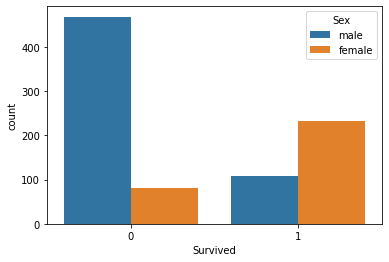

In [457]:
# 성별 생존 현황
sns.countplot(data=train, x='Survived', hue='Sex' )
plt.show()

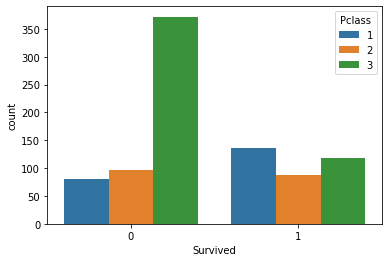

In [458]:
# 티켓등급별 생존 현황
sns.countplot(data=train, x='Survived', hue='Pclass' )
plt.show()

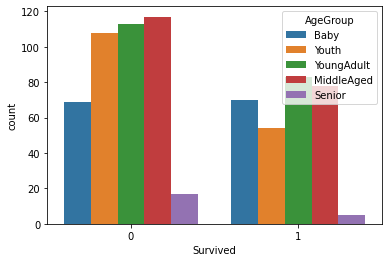

In [459]:
# 나이별 생존 현황

# 나이를 몇개의 등급을 나눈후 처리한다.
bin = [0, 18, 25, 35, 60, 100]
group_names = ['Baby', 'Youth', 'YoungAdult', 'MiddleAged', 'Senior']
train['AgeGroup'] = pd.cut(train['Age'], bins=bin, labels=group_names)
train['AgeGroup'].value_counts()


sns.countplot(data=train, x='Survived', hue='AgeGroup' )
plt.show()

# 원래대로 AgeGroup 컬럼 삭제하기
train.dropna(subset=['AgeGroup'], how='all', inplace=True)

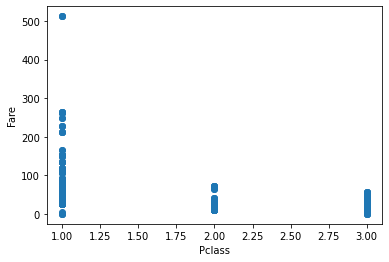

In [460]:
# Pclass와 Fare 관계
plt.scatter(train.Pclass, train.Fare)
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.show()

### 2-2.상관계수로 연관된 필드 확인
- 상관분석(Correlation Analysus) : 두 변수간에 어떤 선형적인 관계를 가지고 있는지를 분석하는 방법
- 상관계수(Correlation coefficient): 두 개의 변수가 같이 일어나는 강도를 나타내는 수치 
- **-1에서 1**사이의 값을 지닙니다. 
- -1이나 1인 수치는 현실 세계에서 관측되기 힘든 수치입니다. 
- 분야별로 기준을 정하는 것에 따라 달라지겠지만, **보통 0.4이상**이면 두 개의 변수간에 상관성이 있다고 얘기합니다. 

![상관계수](https://t1.daumcdn.net/cfile/tistory/99DEE1425C6A9F2008 ) 

#### 상관계수 

In [529]:
train.corr()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Fare2
PassengerId,1.000000,0.029526,-0.035609,-0.024674,0.033681,-0.082704,-0.011672,0.009655,-0.001836,0.009655
Survived,0.029526,1.000000,-0.356462,0.536762,-0.082446,-0.015523,0.095265,0.266100,-0.181979,0.266100
Pclass,-0.035609,-0.356462,1.000000,-0.150826,-0.365902,0.065187,0.023666,-0.552893,0.244145,-0.552893
Sex,-0.024674,0.536762,-0.150826,1.000000,-0.099037,0.106296,0.249543,0.182457,-0.109639,0.182457
Age,0.033681,-0.082446,-0.365902,-0.099037,1.000000,-0.307351,-0.187896,0.093143,-0.032565,0.093143
SibSp,-0.082704,-0.015523,0.065187,0.106296,-0.307351,1.000000,0.383338,0.139860,0.033064,0.139860
Parch,-0.011672,0.095265,0.023666,0.249543,-0.187896,0.383338,1.000000,0.206624,0.011803,0.206624
Fare,0.009655,0.266100,-0.552893,0.182457,0.093143,0.139860,0.206624,1.000000,-0.283510,1.000000
Embarked,-0.001836,-0.181979,0.244145,-0.109639,-0.032565,0.033064,0.011803,-0.283510,1.000000,-0.283510
Fare2,0.009655,0.266100,-0.552893,0.182457,0.093143,0.139860,0.206624,1.000000,-0.283510,1.000000


#### 특정 컬럼과 나머지 컬럼간의 상관계수 계산
- 데이터타입이 숫자일때 가능하다

In [462]:
train.corrwith(train['Fare'])

PassengerId    0.009592
Survived       0.268189
Pclass        -0.554182
Age            0.096067
SibSp          0.138329
Parch          0.205119
Fare           1.000000
dtype: float64

In [530]:
#### Target변수와 상관관계가 높은 순으로 출력

train.corr().loc[:'Embarked', 'Fare'].abs().sort_values(ascending=False)

#상관관계 높은 순 
# > 4.0 : Pclass                          

Fare           1.000000
Pclass         0.552893
Embarked       0.283510
Survived       0.266100
Parch          0.206624
Sex            0.182457
SibSp          0.139860
Age            0.093143
PassengerId    0.009655
Name: Fare, dtype: float64

#### 범주형 데이터로 변환
- 성별(Sex): 0,1인 숫자로 변환

In [463]:
train['Sex'] = train['Sex'].replace('male', 0)
train['Sex'] = train['Sex'].replace('female', 1)
test['Sex'] = test['Sex'].replace('male', 0)
test['Sex'] = test['Sex'].replace('female', 1)

#### 상관계수 시각화하기

<AxesSubplot:>

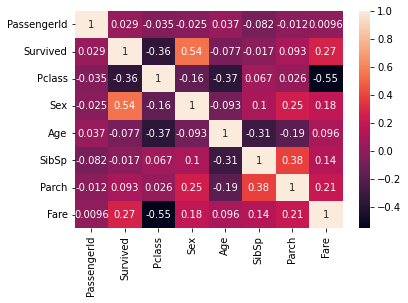

In [464]:
import seaborn as sns

sns.heatmap(train.corr(), annot=True)

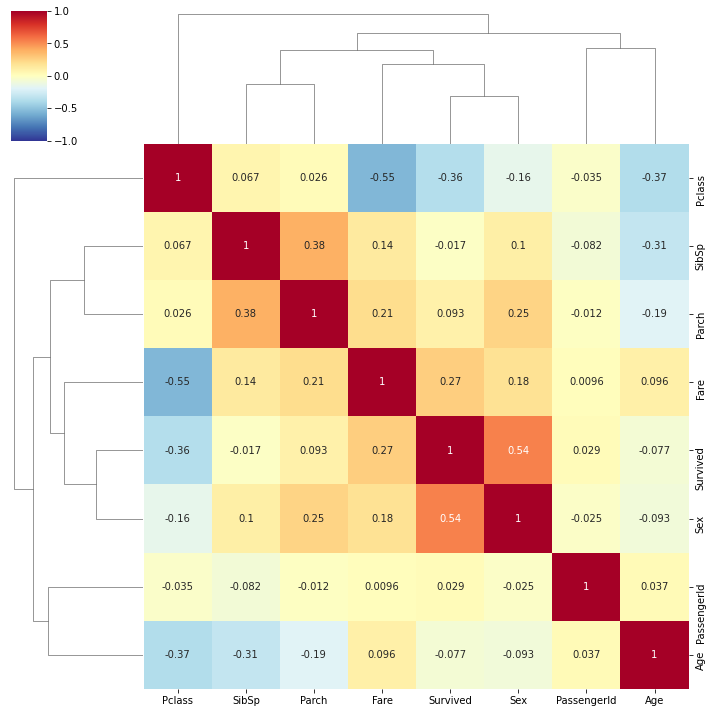

In [465]:
sns.clustermap(train.corr(),
               annot = True,      # 실제 값 화면에 나타내기
               cmap = 'RdYlBu_r',  # Red, Yellow, Blue 색상으로 표시
               vmin = -1, vmax = 1, #컬러차트 -1 ~ 1 범위로 표시
)

#### --> 상관계수를 통해 통해 알 수 있는 내용(0.4 이상인 컬럼명 추출)
**[중요!] 향후 종속변수/독립변수로 사용됨**
- (Sex, Survived), (SibSp,Parch) 양의 상관관계
- (Fare, Pclass) 음의 상관관계

### 2-3.결측치 처리

### # train 결측치 처리

In [466]:
train.info()
# test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 714 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  714 non-null    int64   
 1   Survived     714 non-null    int64   
 2   Pclass       714 non-null    int64   
 3   Name         714 non-null    object  
 4   Sex          714 non-null    int64   
 5   Age          714 non-null    float64 
 6   SibSp        714 non-null    int64   
 7   Parch        714 non-null    int64   
 8   Ticket       714 non-null    object  
 9   Fare         714 non-null    float64 
 10  Cabin        185 non-null    object  
 11  Embarked     712 non-null    object  
 12  AgeGroup     714 non-null    category
dtypes: category(1), float64(2), int64(6), object(4)
memory usage: 73.4+ KB


#### train.info() : Non-Null Count 를 통해 확인한 내용
- **Age** : 결측치 데이터 삭제한다.
- **Cabin** : 피쳐(독립변수)로 사용 안하기 때문에 조치 안한다.
- **Embarked** : 범주형 데이터로 변환한다.(C,Q,S=0,1,2) + 결측치(유사 데이터값으로 채움)

#### 원본데이터를 copy해서 사용함

In [467]:
train2 = train.copy()

#### Age값 결측치 데이터 삭제

In [468]:
train2 = train2[train2['Age'].notna()]
# train2.dropna(subset=['Age'], how='all', inplace=True) #동일 결과

In [469]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 714 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  714 non-null    int64   
 1   Survived     714 non-null    int64   
 2   Pclass       714 non-null    int64   
 3   Name         714 non-null    object  
 4   Sex          714 non-null    int64   
 5   Age          714 non-null    float64 
 6   SibSp        714 non-null    int64   
 7   Parch        714 non-null    int64   
 8   Ticket       714 non-null    object  
 9   Fare         714 non-null    float64 
 10  Cabin        185 non-null    object  
 11  Embarked     712 non-null    object  
 12  AgeGroup     714 non-null    category
dtypes: category(1), float64(2), int64(6), object(4)
memory usage: 73.4+ KB


#### Embarked :  범주형 데이터로 변환(C,Q,S=0,1,2) + 결측치(관련데이터 값으로 변환)

In [470]:
train2.dropna(subset=['Embarked'], how='all', inplace=True)

In [471]:
train2['Embarked'] = train2['Embarked'].replace('C', 0)
train2['Embarked'] = train2['Embarked'].replace('Q', 1)
train2['Embarked'] = train2['Embarked'].replace('S', 2)
# train2.loc[train2['Embarked']=='C', 'Embarked'] = 0 # 결과 동일

In [472]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  712 non-null    int64   
 1   Survived     712 non-null    int64   
 2   Pclass       712 non-null    int64   
 3   Name         712 non-null    object  
 4   Sex          712 non-null    int64   
 5   Age          712 non-null    float64 
 6   SibSp        712 non-null    int64   
 7   Parch        712 non-null    int64   
 8   Ticket       712 non-null    object  
 9   Fare         712 non-null    float64 
 10  Cabin        183 non-null    object  
 11  Embarked     712 non-null    int64   
 12  AgeGroup     712 non-null    category
dtypes: category(1), float64(2), int64(7), object(3)
memory usage: 73.2+ KB


#####  Embarked 컬럼 데이터형 int로 변환 <br>
상관계수를 확인하기 위해 숫자값으로 변환

In [473]:
train2['Embarked'] = train2['Embarked'].astype('int64')

#####  Embarked 필드와 관견있는 컬럼 확인하기(상관계수)

In [474]:
train2.corrwith(train2['Embarked']) 
# Fare          -0.283510와 약간의 음의 상관관계 있음

PassengerId   -0.001836
Survived      -0.181979
Pclass         0.244145
Sex           -0.109639
Age           -0.032565
SibSp          0.033064
Parch          0.011803
Fare          -0.283510
Embarked       1.000000
dtype: float64

##### Embarked.isnull()인 데이터의 'Fare'값 확인

In [475]:
train[train.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
61,62,1,1,"Icard, Miss. Amelie",1,38.0,0,0,113572,80.0,B28,NaN,MiddleAged
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",1,62.0,0,0,113572,80.0,B28,NaN,Senior


##### Fare==80인 데이터 확인

In [476]:
train[train.Fare==80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
61,62,1,1,"Icard, Miss. Amelie",1,38.0,0,0,113572,80.0,B28,NaN,MiddleAged
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",1,62.0,0,0,113572,80.0,B28,NaN,Senior


##### Fare와 상관관계가 높은 Pclass==1인 데이터의 Embarked 데이터 확인

In [477]:
train[train.Pclass==1].Embarked.value_counts()

S    108
C     74
Q      2
Name: Embarked, dtype: int64

##### 결측치(관련데이터 값--> S(2)로 변환)

In [478]:
train2['Embarked'] = train2['Embarked'].fillna("S")
train2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  712 non-null    int64   
 1   Survived     712 non-null    int64   
 2   Pclass       712 non-null    int64   
 3   Name         712 non-null    object  
 4   Sex          712 non-null    int64   
 5   Age          712 non-null    float64 
 6   SibSp        712 non-null    int64   
 7   Parch        712 non-null    int64   
 8   Ticket       712 non-null    object  
 9   Fare         712 non-null    float64 
 10  Cabin        183 non-null    object  
 11  Embarked     712 non-null    int64   
 12  AgeGroup     712 non-null    category
dtypes: category(1), float64(2), int64(7), object(3)
memory usage: 73.2+ KB


#### 원본 변경

In [479]:
train2['Embarked'] = train2['Embarked'].replace('C', 0)
train2['Embarked'] = train2['Embarked'].replace('Q', 1)
train2['Embarked'] = train2['Embarked'].replace('S', 2)

train2['Embarked'] = train2['Embarked'].astype('int64')

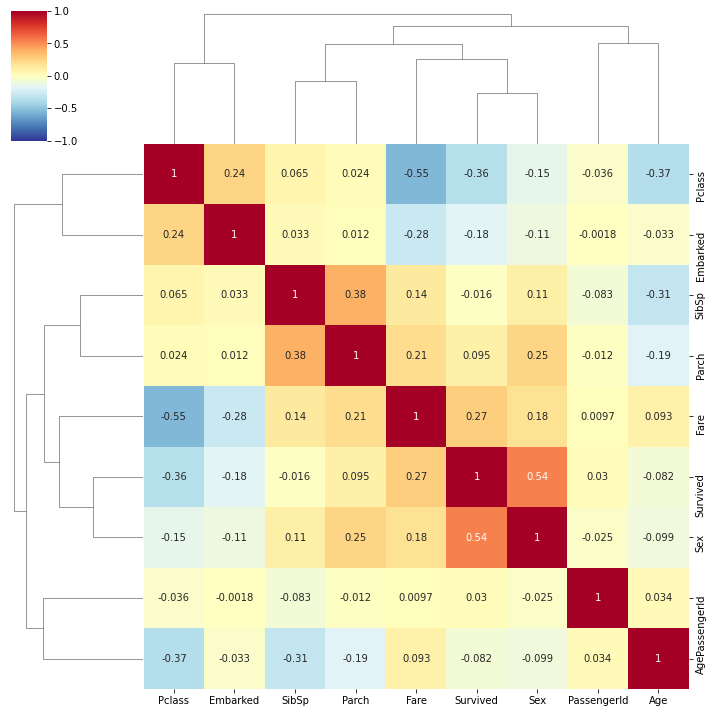

In [480]:
sns.clustermap(train2.corr(),
               annot = True,      # 실제 값 화면에 나타내기
               cmap = 'RdYlBu_r',  # Red, Yellow, Blue 색상으로 표시
               vmin = -1, vmax = 1, #컬러차트 -1 ~ 1 범위로 표시
)

In [481]:
train = train2.copy()

### # test 결측치 처리

In [482]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    int64  
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.0+ KB


#### test.info() : Non-Null Count 를 통해 확인한 내용
- **Age** : 결측치 데이터 삭제한다.
- **Fare** : 결측치(관련성 있는 데이터 값으로 대체)   
- **Cabin** : 피쳐(독립변수)로 사용 안하기 때문에 조치 안한다.
- Embarked :  범주형 데이터로 변환(C,Q,S=0,1,2) 

#### 원본데이터를 copy해서 사용함

In [483]:
test2 = test.copy()

#### Age값 결측치 데이터 삭제

In [484]:
test2 = test2[test2['Age'].notna()]
# test2.dropna(subset=['Age'], how='all', inplace=True) #동일 결과

In [485]:
test2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 332 entries, 0 to 415
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  332 non-null    int64  
 1   Pclass       332 non-null    int64  
 2   Name         332 non-null    object 
 3   Sex          332 non-null    int64  
 4   Age          332 non-null    float64
 5   SibSp        332 non-null    int64  
 6   Parch        332 non-null    int64  
 7   Ticket       332 non-null    object 
 8   Fare         331 non-null    float64
 9   Cabin        87 non-null     object 
 10  Embarked     332 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 31.1+ KB


##### Fare 결측치 확인하기

In [486]:
test[test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",0,60.5,0,0,3701,NaN,NaN,S


#### Fare와 상관관계가 있는 pclass인 데이터 분포 확인하기

In [487]:
test2[test2['Pclass']==3]['Fare'].value_counts()

8.0500     9
7.7750     9
8.6625     8
7.8542     8
7.8958     7
          ..
7.0000     1
14.4542    1
16.7000    1
18.0000    1
20.2500    1
Name: Fare, Length: 64, dtype: int64

##### Fare와 pclass의 데이터 분포에서 많은 비중을 차지하는 데이터 추출: nlargest()
가장 많은 비중을 차지하고 있는 장르를 추출

In [488]:
fare = test2[test2['Pclass']==3]['Fare'].value_counts().nlargest(12)
fare = fare.reset_index()
fare

,index,Fare
0,8.0500,9
1,7.7750,9
2,8.6625,8
3,7.8542,8
4,7.8958,7
5,7.2250,7
6,7.7500,6
7,7.2292,5
8,7.9250,5
9,7.7958,4


#### 가장 많은 비중을 차지하고 있는 장르의 평균값으로 Fare 결측치 값 대체하기

In [489]:
test2['Fare'] = test2['Fare'].fillna( fare['index'].mean() )
test2.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          245
Embarked         0
dtype: int64

#### Embarked :  범주형 데이터로 변환(C,Q,S=0,1,2) 

In [490]:
test2['Embarked'] = test2['Embarked'].replace('C', 0)
test2['Embarked'] = test2['Embarked'].replace('Q', 1)
test2['Embarked'] = test2['Embarked'].replace('S', 2)

test2['Embarked'] = test2['Embarked'].astype('int64')

In [491]:
test = test2.copy()

In [492]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,2
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,1
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,2
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...
409,1301,3,"Peacock, Miss. Treasteall",1,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,2
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",1,37.0,1,0,19928,90.0000,C78,1
412,1304,3,"Henriksson, Miss. Jenny Lovisa",1,28.0,0,0,347086,7.7750,NaN,2
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,108.9000,C105,0


### 2-4.정규화 & 표준화

- **정규화(Normalization)** : -1 ~ 1 사이의 값으로 변환
- **표준화(Standardization)** : 평균이 0이고 표준편차가 1인 값으로 변환
- 머신러닝 성능 향상을 위한 방법
- 정규화와 표준화는 모두 머신러닝 알고리즘을 훈련시키는데 있어서 사용되는 특성(feature)들이 모두 비슷한 영향력을 행사하도록 값을 변환해주는 기술


In [493]:
def normalize(x):
    return (x-x.min())/(x.max()-x.min())

def standardscaler(x):
    return (x-x.mean())/x.std()

#### Fare 정규화&표준화 : 사이킷런의 정규화표준화 클래스 이용

In [494]:
train[['Fare']].head(2)

,Fare
0,7.2500
1,71.2833


In [495]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()
s.fit(train[['Fare']])
train_fare = s.transform(train[['Fare']])
test_fare = s.transform(test[['Fare']])

# 정규화표준화된 값으로 신규컬럼 추가
train['Fare2'] = train_fare
test['Fare2'] = test_fare

# 데이터 형 변환
train['Fare2'] = train['Fare2'].astype('float64')
test['Fare2'] = test['Fare2'].astype('float64')

#### 최종 종속변수와 독립변수
- 'Age' 컬럼을 종속변수로 사용하지 않는 이유: 편차가 너무 크고 null값이 너무 많았기 때문.
- **종속변수** : Survived 
- **독립변수** : Pclass, Sex, SibSp, Parch, Fare(Fare2), Embarked     

In [496]:
data = train[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare2', 'Embarked','Survived']]
dataT= test[['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare2', 'Embarked']]
data.head()

,Pclass,Sex,SibSp,Parch,Fare2,Embarked,Survived
0,3,0,1,0,-0.516380,2,0
1,1,1,1,0,0.694046,0,1
2,3,1,0,0,-0.503620,2,1
3,1,1,1,0,0.350326,2,1
4,3,0,0,0,-0.501257,2,0


In [497]:
dataT.head()

,Pclass,Sex,SibSp,Parch,Fare2,Embarked
0,3,0,0,0,-0.505431,1
1,3,1,1,0,-0.521106,2
2,2,0,0,0,-0.470304,1
3,3,0,0,0,-0.489679,2
4,3,1,1,1,-0.421156,2


### 2-5. 시각화

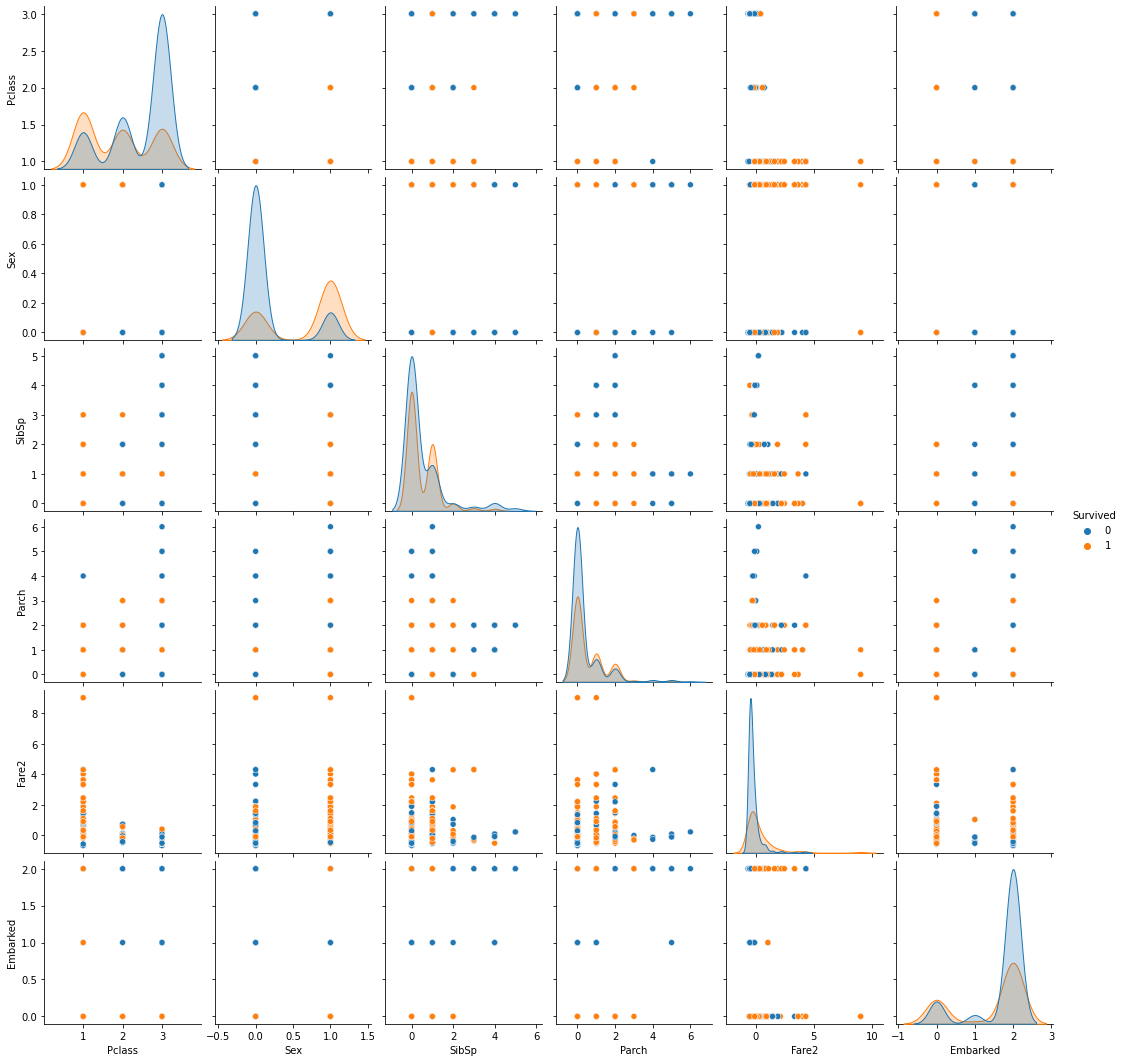

In [498]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data, hue='Survived')
plt.show()

In [499]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    int64  
 2   SibSp     712 non-null    int64  
 3   Parch     712 non-null    int64  
 4   Fare2     712 non-null    float64
 5   Embarked  712 non-null    int64  
 6   Survived  712 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 60.7 KB


---------------------

## 3. 모델링

### 3-1. 학습용 데이터 준비

In [500]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    int64  
 2   SibSp     712 non-null    int64  
 3   Parch     712 non-null    int64  
 4   Fare2     712 non-null    float64
 5   Embarked  712 non-null    int64  
 6   Survived  712 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 60.7 KB


In [501]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 332 entries, 0 to 415
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  332 non-null    int64  
 1   Pclass       332 non-null    int64  
 2   Name         332 non-null    object 
 3   Sex          332 non-null    int64  
 4   Age          332 non-null    float64
 5   SibSp        332 non-null    int64  
 6   Parch        332 non-null    int64  
 7   Ticket       332 non-null    object 
 8   Fare         332 non-null    float64
 9   Cabin        87 non-null     object 
 10  Embarked     332 non-null    int64  
 11  Fare2        332 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 33.7+ KB


In [514]:
X = data.iloc[:,:6].values
y = data.iloc[:,6].values
X, y

(array([[ 3.        ,  0.        ,  1.        ,  0.        , -0.51637992,
          2.        ],
        [ 1.        ,  1.        ,  1.        ,  0.        ,  0.69404605,
          0.        ],
        [ 3.        ,  1.        ,  0.        ,  0.        , -0.50362035,
          2.        ],
        ...,
        [ 1.        ,  1.        ,  0.        ,  0.        , -0.08633507,
          2.        ],
        [ 1.        ,  0.        ,  0.        ,  0.        , -0.08633507,
          0.        ],
        [ 3.        ,  0.        ,  0.        ,  0.        , -0.50692839,
          1.        ]]),
 array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
        0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0

In [505]:
data.columns.values[:6]

array(['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare2', 'Embarked'],
      dtype=object)

### 3-2. 학습용, 테스트 데이터 분리하기

In [506]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

# X_train, X_test, y_train = X, dataT.iloc[:,:].values, y 

### 3-3.모델 훈련 및 테스트, 성능평가

#### # 로직스틱 회귀 : LogisticRegression()
- 분류에 적용 시그이드 함수 사용 
- 평가 지표 : 오차행렬(confusion_matrix) 정확도 사용

y_pred size : (712,)
acc : 0.7552447552447552


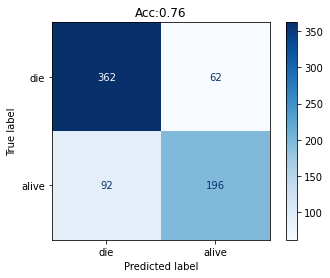

정확도 : 0.7837078651685393
정밀도 : 0.7596899224806202
재현율 : 0.6805555555555556
F1    : 0.717948717948718
ROC_ACU : 0.7671645702306079


In [508]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 
import numpy as np

# 학습모델(분류) : 로지스틱 회귀
model = LogisticRegression()
# 모델 훈련
model.fit(X_train, y_train)
# 예측
y_pred = model.predict(X)
print(f'y_pred size : {y_pred.shape}')


# 정확도 출력
acc = model.score(X_test, y_test)
print(f'acc : {acc}')


# 혼돈행렬 시각화
labels = 'die','alive'
cm = confusion_matrix(y, y_pred) # 혼돈 행렬 구하기
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
plt.title(f'Acc:{np.round(acc,2)}')
plt.show()

# 평가지표
accuracy = accuracy_score(y, y_pred)
precision= precision_score(y, y_pred)
recall   = recall_score(y, y_pred)
f1       = f1_score(y, y_pred)
roc_auc  = roc_auc_score(y, y_pred)
print(f'정확도 : {accuracy}')
print(f'정밀도 : {precision}')
print(f'재현율 : {recall}')
print(f'F1    : {f1}')
print(f'ROC_ACU : {roc_auc}')

#### 테스트 데이터 넣어서 예측하기

In [527]:
# test_val = dataT.values
# y_pred = model.predict(test_val)
# dataT['pred'] = y_pred
# dataT

#### # 의사결정트리: DecisionTreeClassifier()
- 직관적으로 이해하기 쉬운 것으로 다중 분류에 많이 사용함. if/else기반의 규칙을 찾아 학습.if(Decision Node)/then(Leaf Node)
- 데이터의 균일도를 최대로 높게 만드는 규칙을 찾아서 규칙 노드로 구성해야함. 
- 데이터의 균일도 계산하는 방법 : 정보 이득 지수(entropy:혼잡도), 지니 계수(gini coefficient:데이터의 순서,낮으면 균일도 높음)
- 지니계수가 낮은 피처를 분할 기준으로 사용한다.    
- 평가 지표 : 오차행렬(confusion_matrix) 정확도 사용

In [509]:
!pip install graphviz

In [510]:
import graphviz

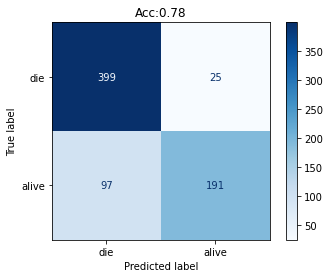

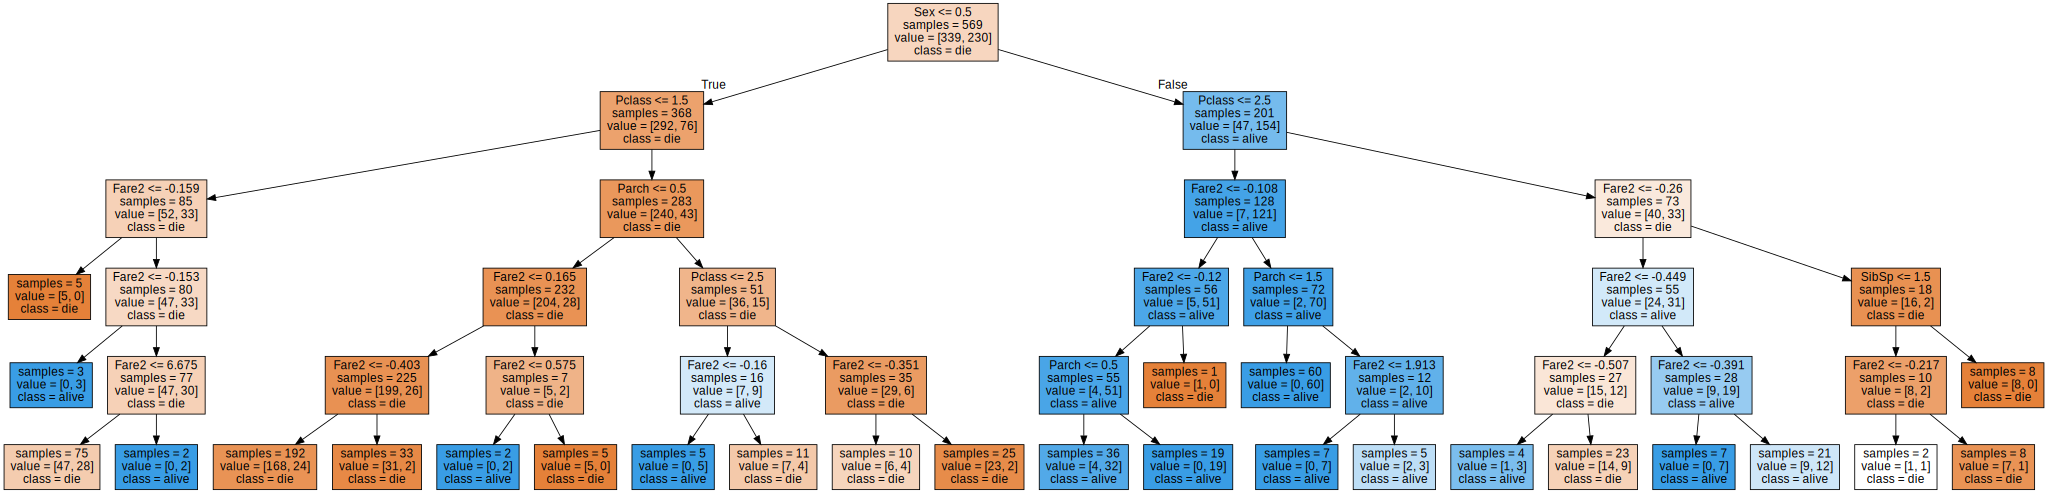

정확도 : 0.8286516853932584
정밀도 : 0.8842592592592593
재현율 : 0.6631944444444444
F1    : 0.7579365079365079
ROC_ACU : 0.8021160901467504


In [516]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import graphviz

# 학습모델(분류) : 의사결정트리
model = DecisionTreeClassifier(criterion='gini', max_depth=5)

model.fit(X_train, y_train)

y_pred = model.predict(X)


# 정확도 출력
acc = model.score(X_test, y_test)


# 혼돈행렬 시각화
labels = 'die','alive'
cm = confusion_matrix(y, y_pred) # 혼돈 행렬 구하기
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')

plt.title(f'Acc:{np.round(acc,2)}')
plt.show()


# 결정 트리인 경우 트리 시각화
# plot_tree 사용방법
# plt.figure(figsize=(20,10))
# plot_tree(model)
# plt.savefig('decisiontree.png')
# plt.show()


# graphviz 사용방법
export_graphviz(model, out_file="tree.dot", 
                class_names = ['die','alive'], feature_names = data.columns[:6].values, 
                impurity=False, filled=True)
with open("tree.dot" ,encoding="UTF-8") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))
graphviz.Source(dot_graph).render('tree', format="png")



# 평가지표
accuracy = accuracy_score(y, y_pred)
precision= precision_score(y, y_pred)
recall   = recall_score(y, y_pred)
f1       = f1_score(y, y_pred)
roc_auc  = roc_auc_score(y, y_pred)
print(f'정확도 : {accuracy}')
print(f'정밀도 : {precision}')
print(f'재현율 : {recall}')
print(f'F1    : {f1}')
print(f'ROC_ACU : {roc_auc}')

#### # 서포트벡터머신(Support Vector Classifier): SVM()
- 분류를 위한 기준 선(결정 경계: Decision Boundary)을 정의하는 모델
- Support Vectors는 결정 경계와 가까이 있는 데이터 포인트들을 의미한다
- 최적의 결정 경계는 결정 경계와 서포트 벡터 사이의 거리를 의미하는 마진을 최대화한다

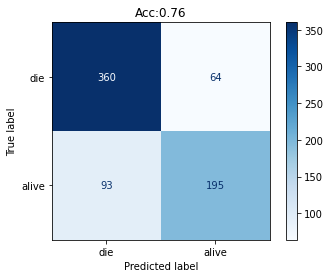

정확도 : 0.7794943820224719
정밀도 : 0.752895752895753
재현율 : 0.6770833333333334
F1    : 0.7129798903107861
ROC_ACU : 0.7630699685534592


In [517]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 학습모델(분류) : 서포트벡터머신
model = SVC(kernel='linear', random_state=1)

model.fit(X_train, y_train)

y_pred = model.predict(X)


# 정확도 출력
acc = model.score(X_test, y_test)


# 혼돈행렬 시각화
labels = 'die','alive'
cm = confusion_matrix(y, y_pred) # 혼돈 행렬 구하기
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
plt.title(f'Acc:{np.round(acc,2)}')
plt.show()


# 평가지표
accuracy = accuracy_score(y, y_pred)
precision= precision_score(y, y_pred)
recall   = recall_score(y, y_pred)
f1       = f1_score(y, y_pred)
roc_auc  = roc_auc_score(y, y_pred)
print(f'정확도 : {accuracy}')
print(f'정밀도 : {precision}')
print(f'재현율 : {recall}')
print(f'F1    : {f1}')
print(f'ROC_ACU : {roc_auc}')

----------------------

끝